### Model Choice
A Random Forest regression model was chosen because it is well suited for capturing complex, non-linear relationships between Instagram activity and electoral outcomes. Exploratory analysis indicated that the relationship between social media metrics and vote counts is not strictly linear, particularly at higher levels of follower count. Random Forests can model such non-linearities and interaction effects without requiring explicit specification.
Additionally, Random Forests are robust to outliers and can handle a mixture of continuous and categorical variables, which is particularly relevant in this context, where Instagram metrics are highly skewed and political variables such as party affiliation and municipality are included as controls. Compared to linear models, Random Forests therefore offer greater flexibility while remaining interpretable through feature importance analysis.
Finally, Random Forests perform well on relatively small datasets and are less prone to overfitting than single decision trees, making them appropriate for the available number of observations.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

path = '../../data-wrangling/preprocessing/instagram/2025-votes-candidates-instagram.csv'
df = pd.read_csv(path)

# --- 1) Create missingness flags + fill NaNs (must happen BEFORE feature engineering) ---
df["missing_followers"] = df["Follower Count"].isna().astype(int)
df["missing_posts"] = df["Number of Posts"].isna().astype(int)

df["Follower Count"] = df["Follower Count"].fillna(0)
df["Number of Posts"] = df["Number of Posts"].fillna(0)

# Optional safety if municipality has NaNs
df["municipality"] = df["municipality"].fillna("Unknown")

# --- 2) Feature engineering ---
df["log_followers"] = np.log1p(df["Follower Count"])
df["log_posts"] = np.log1p(df["Number of Posts"])

df["posts_per_follower"] = df["Number of Posts"] / (df["Follower Count"] + 1)
df["visibility"] = df["Follower Count"] * np.log1p(df["Number of Posts"])
df["interaction"] = df["Follower Count"] * df["Number of Posts"]

# --- 3) Target ---
y = np.log1p(df["Stemmetal"])

# --- 4) Feature matrix ---
feature_cols = [
    "log_followers",
    "log_posts",
    "posts_per_follower",
    "visibility",
    "interaction",
    "missing_followers",
    "missing_posts",
    "Listenavn",
    "municipality"
]

X = df[feature_cols].copy()
X = pd.get_dummies(X, columns=["Listenavn", "municipality"], drop_first=True)

# --- 5) Sanity checks ---
assert X.isna().sum().sum() == 0, "X still contains NaNs"
assert y.isna().sum() == 0, "y contains NaNs"

print("X shape:", X.shape)
print("y shape:", y.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE (log votes):", rmse)
print("R²:", r2)

import pandas as pd

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)


X shape: (410, 35)
y shape: (410,)
RMSE (log votes): 1.2851030839644841
R²: 0.28297255818672384


log_followers                                 0.350071
visibility                                    0.130904
interaction                                   0.106080
municipality_Frederiksberg                    0.097543
log_posts                                     0.055469
posts_per_follower                            0.053629
Listenavn_Enhedslisten - De Rød-Grønne        0.031729
Listenavn_Venstre, Danmarks Liberale Parti    0.024174
Listenavn_SF - Socialistisk Folkeparti        0.022614
Listenavn_Kommunistisk Parti                  0.020753
dtype: float64

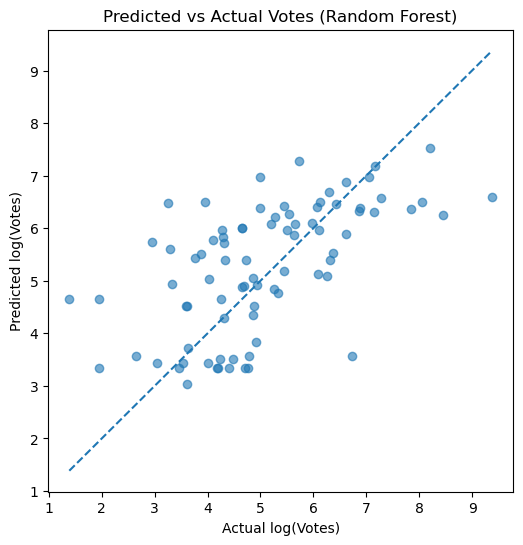

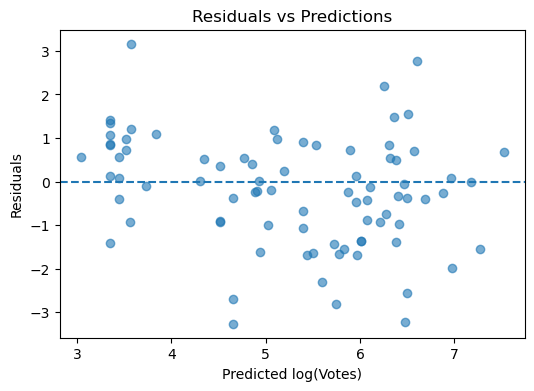

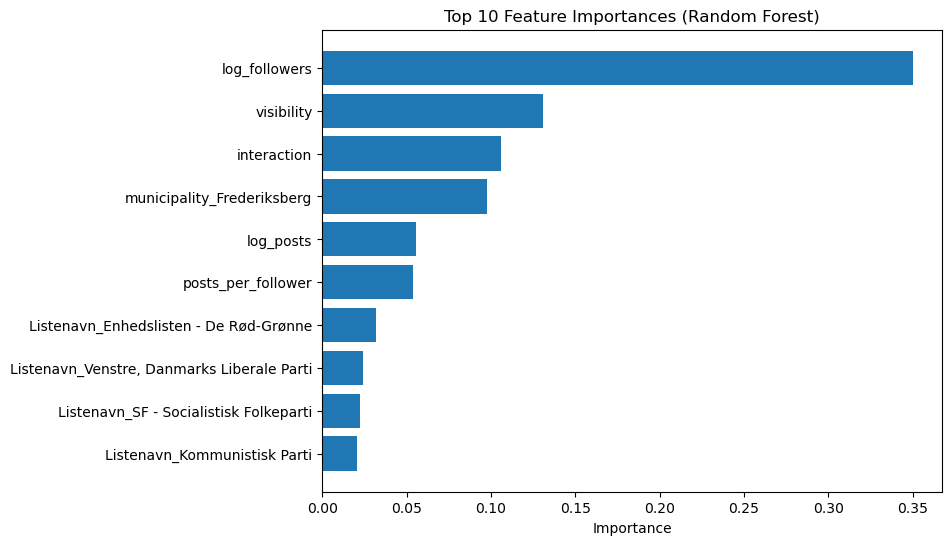

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.xlabel("Actual log(Votes)")
plt.ylabel("Predicted log(Votes)")
plt.title("Predicted vs Actual Votes (Random Forest)")
plt.show()

residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log(Votes)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,6))
plt.barh(importances.index[-10:], importances.values[-10:])
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()



The predicted-versus-actual plot shows that the Random Forest model captures the overall relationship between Instagram metrics and vote counts, with predictions increasing consistently with actual votes. However, extreme vote outcomes are systematically underpredicted, indicating regression toward the mean. The residual plot shows no strong systematic patterns, suggesting that remaining errors are largely driven by unobserved factors rather than model misspecification. Together, these diagnostics indicate that the model captures general trends while acknowledging substantial inherent uncertainty.

### Model Performance 
A Random Forest regression model was trained to predict log-transformed candidate vote counts using Instagram-derived features, party affiliation, and municipality. The model achieved an R² of 0.28 and an RMSE of 1.29 in log-vote space, indicating moderate predictive performance. Given the complexity and noise inherent in individual-level electoral behavior, this level of explanatory power is consistent with expectations.

### Feature Importance 
Feature importance analysis reveals that Instagram follower count is by far the most influential predictor, accounting for approximately 35% of total importance. Combined reach–activity measures such as visibility and interaction terms further contribute to predictive power, while posting frequency alone plays a relatively minor role. Municipality also emerges as an important factor, confirming contextual differences between Copenhagen and Frederiksberg. Party affiliation contributes modestly to prediction but is less influential than social media reach.

### Conclusion
Overall, the model supports the conclusion that Instagram reach substantially increases a candidate’s electoral potential, while posting activity alone has limited impact. Social media metrics explain a meaningful share of vote variation but do not fully account for electoral outcomes, highlighting the importance of additional political and contextual factors.

### Answer to research question
The analysis demonstrates a clear positive association between Instagram follower count and electoral success for both parties and individual politicians. Candidates with larger follower bases consistently receive more votes, while posting frequency alone shows only a weak relationship with vote totals. Predictive modeling confirms that Instagram followers are the strongest single social media predictor, explaining a substantial share of vote variation, but they are insufficient on their own to fully predict electoral outcomes. Party affiliation, municipality, and other unobserved factors remain important, indicating that Instagram presence increases electoral potential rather than determining success outright.

Instagram follower count is positively and strongly associated with vote counts for individual politicians, while the number of posts alone shows only a weak relationship. Predictive modeling demonstrates that follower count is the single most important Instagram-based predictor, explaining a substantial share of vote variation. However, the model’s limited performance and its tendency to underpredict extreme outcomes indicate that Instagram metrics alone cannot fully predict electoral success. Instead, social media reach increases a candidate’s potential for higher vote counts, but party affiliation, municipality, and other unobserved political factors remain essential.

### Limitations
A Random Forest regression model was chosen because it is well suited for capturing complex, non-linear relationships between Instagram activity and electoral outcomes. Exploratory analysis indicated that the relationship between social media metrics and vote counts is not strictly linear, particularly at higher levels of follower count. Random Forests can model such non-linearities and interaction effects without requiring explicit specification.
Additionally, Random Forests are robust to outliers and can handle a mixture of continuous and categorical variables, which is particularly relevant in this context, where Instagram metrics are highly skewed and political variables such as party affiliation and municipality are included as controls. Compared to linear models, Random Forests therefore offer greater flexibility while remaining interpretable through feature importance analysis.
Finally, Random Forests perform well on relatively small datasets and are less prone to overfitting than single decision trees, making them appropriate for the available number of observations.

### Instagram presence increases the likelihood of higher vote counts but does not determine electoral success and cannot be used as a standalone predictive tool.


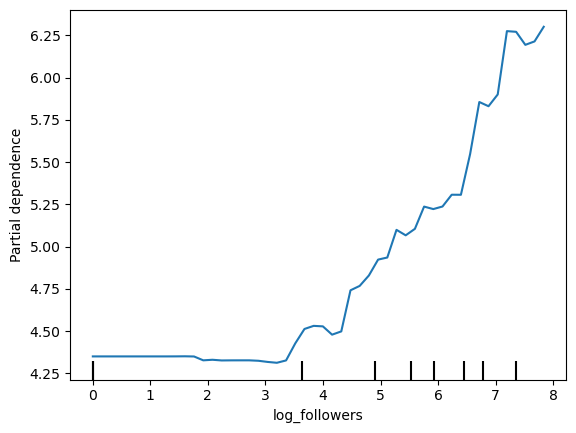

In [3]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    rf,
    X_train,
    features=["log_followers"],
    grid_resolution=50
)


The partial dependence plot for Instagram follower count shows a strongly non-linear relationship with predicted vote totals. At low follower levels, increases in followers have little effect on predicted votes. Beyond a threshold, however, additional followers are associated with rapidly increasing vote counts, followed by diminishing returns at very high levels. This supports the conclusion that Instagram reach enhances electoral potential but does not linearly translate into votes.

In [4]:
from pathlib import Path
import os
import matplotlib as mpl

# Make sure TeX binaries are visible
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

# Force PGF backend + pdflatex
mpl.use("pgf")
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "text.usetex": False,
    "font.family": "serif",})

Path("latex").mkdir(parents=True, exist_ok=True)

df_pred = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred
})

# 5 equal-frequency bins based on predicted values
df_pred["bin"] = pd.qcut(df_pred["y_pred"], q=5, duplicates="drop")

# Mean actual/predicted within each bin
bin_means = (
    df_pred.groupby("bin", observed=True)[["y_true", "y_pred"]]
    .mean()
    .reset_index()
)

# Use bin midpoints as x-axis (numeric, plots nicely)
bin_means["bin_mid"] = bin_means["bin"].apply(lambda iv: 0.5 * (iv.left + iv.right))
bin_means = bin_means.sort_values("bin_mid")

plt.figure(figsize=(7, 5))
plt.plot(bin_means["bin_mid"], bin_means["y_true"], marker="o", label="Mean actual (y_true)")
plt.plot(bin_means["bin_mid"], bin_means["y_pred"], marker="o", label="Mean predicted (y_pred)")

plt.xlabel("Predicted vote quantile bin (midpoint of y_pred bin)")
plt.ylabel("Mean value")
plt.title("Binned means: actual vs predicted")
plt.legend()
plt.tight_layout()

plt.savefig("latex/binned_means_actual_vs_predicted.png")
plt.show()


/var/folders/jj/hsg2m7191lv7fy094sdtz54h0000gn/T/ipykernel_47636/690846550.py:47: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()


A binned comparison of predicted and observed vote counts shows that the Random Forest model captures the overall ordering of candidates but consistently overestimates vote totals, particularly among high-performing candidates. This suggests that Instagram-related features provide useful signals of electoral strength but fail to fully account for factors driving exceptional electoral outcomes.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create a DataFrame with actual and predicted values
df_pred = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

# Create bins based on actual values (quantiles)
df_pred["bin"] = pd.qcut(df_pred["actual"], q=5)

# Compute mean actual and predicted per bin
bin_summary = (
    df_pred
    .groupby("bin", observed=True)
    .agg(
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean")
    )
)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(
    bin_summary["actual_mean"],
    bin_summary["predicted_mean"],
    marker="o"
)

# Reference line
plt.plot(
    bin_summary["actual_mean"],
    bin_summary["actual_mean"],
    linestyle="--",
    color="gray"
)

plt.xlabel("Mean actual log(votes)")
plt.ylabel("Mean predicted log(votes)")
plt.title("Binned Actual vs Predicted Votes (Random Forest)")
plt.tight_layout()
plt.show()
plt.savefig("binned_actual_vs_predicted.png", dpi=300, bbox_inches="tight")



/var/folders/jj/hsg2m7191lv7fy094sdtz54h0000gn/T/ipykernel_47636/7641703.py:44: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()


In [10]:
# Compute residuals
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_test, residuals, alpha=0.6)
plt.axhline(0, linestyle="--", color="gray")

plt.xlabel("Actual log(votes)")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals vs Actual Votes (Random Forest)")
plt.tight_layout()
plt.show()
plt.savefig("residuals.png", dpi=300, bbox_inches="tight")

/var/folders/jj/hsg2m7191lv7fy094sdtz54h0000gn/T/ipykernel_47636/3063932183.py:12: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()
